# 04 — Diebold–Mariano Tests & Thesis Visuals

DM тесты для всех пар моделей + публикационные графики.

**Требуется**: сначала `main.py`

In [1]:
import sys, os
ROOT = r'D:\clode9'
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from scipy import stats

from thesis_app.pipeline import load_config, build_paths, diebold_mariano, inv_fisher_z, dm_to_latex

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

cfg   = load_config(os.path.join(ROOT, 'config.yaml'))
paths = build_paths(cfg['base_dir'])

csv_files = sorted(glob(os.path.join(paths.predictions, '*_predictions.csv')))
experiments = {os.path.basename(f).replace('_predictions.csv',''):
               pd.read_csv(f, index_col=0, parse_dates=True) for f in csv_files}
print(f'Loaded {len(experiments)} experiments')
print(list(experiments.keys())[:4], '...')


Loaded 24 experiments
['corr_BTC-USD_ETH-USD_w14_fisher_z', 'corr_BTC-USD_ETH-USD_w30_fisher_z', 'corr_BTC-USD_ETH-USD_w60_fisher_z', 'corr_BTC-USD_ETH-USD_w90_fisher_z'] ...


In [2]:
# ── DM тесты для всех пар моделей ────────────────────────────────
DM_NW_LAG = int(cfg.get('dm_nw_lag', 0))
MODEL_PAIRS = [
    ('XGB_GPU', 'DCC_GARCH'),
    ('XGB_GPU', 'Naive_Last'),
    ('XGB_GPU', 'Ridge'),
    ('Ridge',   'DCC_GARCH'),
    ('Ridge',   'Naive_Last'),
    ('DCC_GARCH', 'Naive_Last'),
    ('RF',      'DCC_GARCH'),
    ('RF',      'Naive_Last'),
]

dm_rows = []
for exp_key, df in experiments.items():
    parts = exp_key.split('_w')
    dep = parts[0]
    w_parts = parts[1].split('_', 1) if len(parts) > 1 else ['0', 'unknown']
    window = int(w_parts[0]) if w_parts[0].isdigit() else 0
    space = w_parts[1] if len(w_parts) > 1 else ''

    y_true = df['y_true']
    avail = [c for c in df.columns if c != 'y_true']

    for m1, m2 in MODEL_PAIRS:
        m1_actual = m1 if m1 in avail else ('XGB_CPU' if m1 == 'XGB_GPU' and 'XGB_CPU' in avail else None)
        if not m1_actual or m2 not in avail:
            continue
        e1 = (y_true - df[m1_actual]).values
        e2 = (y_true - df[m2]).values
        dm = diebold_mariano(e1, e2, h=1, nw_lag=DM_NW_LAG)
        dm_rows.append({'dependency': dep, 'window': window, 'space': space,
                        'model': m1, 'benchmark': m2, **dm})

dm_df = pd.DataFrame(dm_rows)
dm_df['significant'] = dm_df['p_value'].apply(
    lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else '')) if pd.notna(p) else '')
dm_df['model_better'] = dm_df['DM_stat'].apply(lambda x: x > 0 if pd.notna(x) else False)

dm_df.to_csv(os.path.join(paths.results, 'dm_tests_full.csv'), index=False)
print(f'Saved {len(dm_df)} DM tests')
dm_df.head(8)


Saved 192 DM tests


,dependency,window,space,model,benchmark,DM_stat,p_value,n,significant,model_better
0,corr_BTC-USD_ETH-USD,14,fisher_z,XGB_GPU,DCC_GARCH,18.198591,0.000000e+00,2150,***,True
1,corr_BTC-USD_ETH-USD,14,fisher_z,XGB_GPU,Naive_Last,-13.146264,0.000000e+00,2150,***,False
2,corr_BTC-USD_ETH-USD,14,fisher_z,XGB_GPU,Ridge,-5.680886,1.521936e-08,2150,***,False
3,corr_BTC-USD_ETH-USD,14,fisher_z,Ridge,DCC_GARCH,20.108374,0.000000e+00,2150,***,True
4,corr_BTC-USD_ETH-USD,14,fisher_z,Ridge,Naive_Last,-10.208571,0.000000e+00,2150,***,False
5,corr_BTC-USD_ETH-USD,14,fisher_z,DCC_GARCH,Naive_Last,-22.988370,0.000000e+00,2150,***,False
6,corr_BTC-USD_ETH-USD,14,fisher_z,RF,DCC_GARCH,19.673611,0.000000e+00,2150,***,True
7,corr_BTC-USD_ETH-USD,14,fisher_z,RF,Naive_Last,-11.778819,0.000000e+00,2150,***,False


In [3]:
# ── Сводка: XGB vs DCC ───────────────────────────────────────────
xgb_vs_dcc = dm_df[(dm_df['model'] == 'XGB_GPU') & (dm_df['benchmark'] == 'DCC_GARCH')]
print('XGB_GPU vs DCC_GARCH:')
print(xgb_vs_dcc[['dependency','window','DM_stat','p_value','significant','model_better']].to_string(index=False))
print(f'\nXGB better: {xgb_vs_dcc["model_better"].sum()}/{len(xgb_vs_dcc)}')


XGB_GPU vs DCC_GARCH:
          dependency  window   DM_stat  p_value significant  model_better
corr_BTC-USD_ETH-USD      14 18.198591      0.0         ***          True
corr_BTC-USD_ETH-USD      30 18.393137      0.0         ***          True
corr_BTC-USD_ETH-USD      60 19.792495      0.0         ***          True
corr_BTC-USD_ETH-USD      90 23.850672      0.0         ***          True
    corr_BTC-USD_GLD      14 20.829044      0.0         ***          True
    corr_BTC-USD_GLD      30 28.138741      0.0         ***          True
    corr_BTC-USD_GLD      60 31.178050      0.0         ***          True
    corr_BTC-USD_GLD      90 29.903299      0.0         ***          True
    corr_BTC-USD_SLV      14 25.146489      0.0         ***          True
    corr_BTC-USD_SLV      30 31.927300      0.0         ***          True
    corr_BTC-USD_SLV      60 32.267517      0.0         ***          True
    corr_BTC-USD_SLV      90 31.386549      0.0         ***          True
    corr_BTC-USD

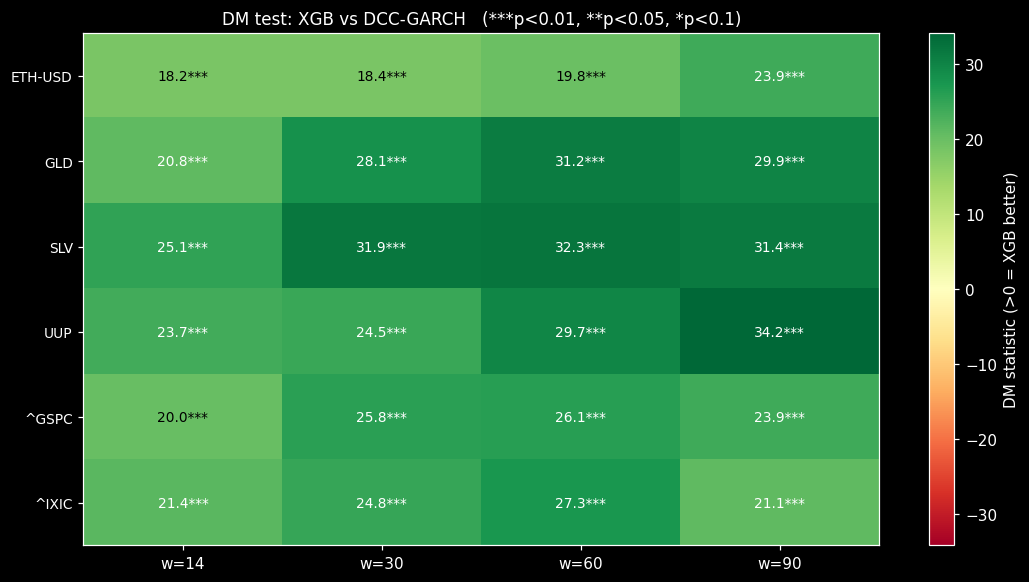

In [4]:
# ── DM heatmap: XGB vs DCC ───────────────────────────────────────
hm = xgb_vs_dcc.copy()
hm['pair'] = hm['dependency'].str.replace('corr_BTC-USD_', '', regex=False)

try:
    pivot_dm = hm.pivot_table(index='pair', columns='window', values='DM_stat', aggfunc='first')
    vals = pivot_dm.values.astype(float)
    vmax = np.nanmax(np.abs(vals)) if not np.all(np.isnan(vals)) else 5.0

    fig, ax = plt.subplots(figsize=(10, max(4, len(pivot_dm) * 0.9)))
    im = ax.imshow(vals, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(pivot_dm.columns)))
    ax.set_xticklabels([f'w={w}' for w in pivot_dm.columns])
    ax.set_yticks(range(len(pivot_dm.index)))
    ax.set_yticklabels(pivot_dm.index, fontsize=9)
    for i in range(len(pivot_dm.index)):
        for j in range(len(pivot_dm.columns)):
            v = vals[i, j]
            if not np.isnan(v):
                sig = hm[(hm['pair']==pivot_dm.index[i]) & (hm['window']==pivot_dm.columns[j])]['significant'].values
                s = sig[0] if len(sig) > 0 else ''
                ax.text(j, i, f'{v:.1f}{s}', ha='center', va='center', fontsize=9,
                        color='white' if abs(v) > vmax * 0.6 else 'black')
    plt.colorbar(im, ax=ax, label='DM statistic (>0 = XGB better)')
    ax.set_title('DM test: XGB vs DCC-GARCH   (***p<0.01, **p<0.05, *p<0.1)', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(paths.figures, 'dm_heatmap_XGB_vs_DCC.png'), dpi=130)
    plt.show()
except Exception as e:
    print(f'Heatmap error: {e}')


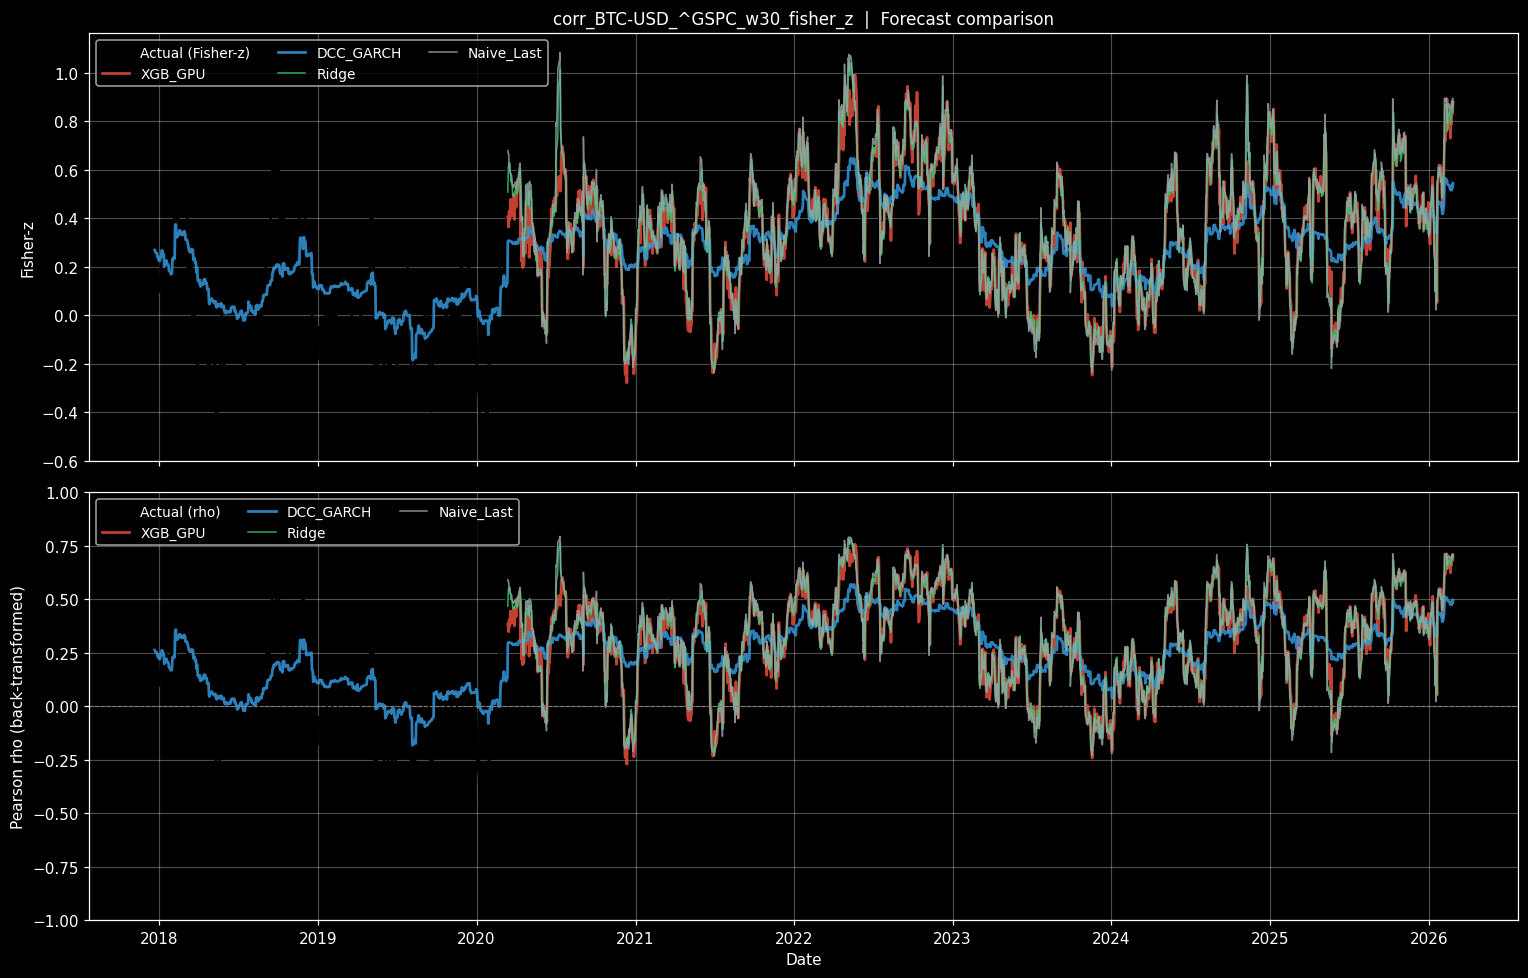

Saved.


In [5]:
# ── Publication forecast plot ─────────────────────────────────────
SHOWCASE = 'corr_BTC-USD_^GSPC_w30_fisher_z'
if SHOWCASE not in experiments:
    SHOWCASE = list(experiments.keys())[0]
    print(f'Using: {SHOWCASE}')

df = experiments[SHOWCASE]
y_true = df['y_true']
COLORS = {'XGB_GPU': '#e74c3c', 'XGB_CPU': '#e74c3c', 'DCC_GARCH': '#3498db',
          'Ridge': '#2ecc71', 'Naive_Last': '#95a5a6', 'RF': '#9b59b6', 'GBM': '#e67e22'}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top: Fisher-z
ax = axes[0]
ax.plot(y_true.index, y_true, label='Actual (Fisher-z)', color='black', lw=1.8)
for m in ['XGB_GPU','XGB_CPU','DCC_GARCH','Ridge','Naive_Last']:
    if m in df.columns and df[m].notna().sum() > 50:
        ax.plot(df.index, df[m], label=m, color=COLORS.get(m,'gray'),
                lw=1.8 if m in ('XGB_GPU','XGB_CPU','DCC_GARCH') else 1.0, alpha=0.85)
ax.set_ylabel('Fisher-z')
ax.set_title(f'{SHOWCASE}  |  Forecast comparison', fontsize=11)
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.3)

# Bottom: raw corr
ax2 = axes[1]
ax2.plot(y_true.index, inv_fisher_z(y_true), label='Actual (rho)', color='black', lw=1.8)
for m in ['XGB_GPU','XGB_CPU','DCC_GARCH','Ridge','Naive_Last']:
    if m in df.columns and df[m].notna().sum() > 50:
        ax2.plot(df.index, inv_fisher_z(df[m]), label=m, color=COLORS.get(m,'gray'),
                 lw=1.8 if m in ('XGB_GPU','XGB_CPU','DCC_GARCH') else 1.0, alpha=0.85)
ax2.axhline(0, color='gray', lw=0.7, ls='--')
ax2.set_ylabel('Pearson rho (back-transformed)')
ax2.set_xlabel('Date')
ax2.legend(ncol=3, fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_ylim(-1, 1)

plt.tight_layout()
plt.savefig(os.path.join(paths.figures, f'thesis_forecast_{SHOWCASE}.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')


In [6]:
# ── DM сводная таблица и LaTeX ────────────────────────────────────
summary = dm_df.groupby(['model','benchmark']).agg(
    n_tests=('DM_stat', 'count'),
    n_sig=('significant', lambda x: (x != '').sum()),
    n_better=('model_better', 'sum'),
    mean_DM=('DM_stat', 'mean'),
).round(3)
print('DM summary:')
print(summary.to_string())

tex_path = os.path.join(paths.tables, 'dm_tests_full.tex')
dm_to_latex(dm_df, tex_path)
print(f'LaTeX saved: {tex_path}')
print('DM tests complete.')


DM summary:
                      n_tests  n_sig  n_better  mean_DM
model     benchmark                                    
DCC_GARCH Naive_Last       24     24         0  -28.592
RF        DCC_GARCH        24     24        24   25.870
          Naive_Last       24     24         0  -12.659
Ridge     DCC_GARCH        24     24        24   26.444
          Naive_Last       24     24         0  -10.442
XGB_GPU   DCC_GARCH        24     24        24   25.560
          Naive_Last       24     24         0  -13.935
          Ridge            24     24         0   -8.360
LaTeX saved: D:/clode9\outputs\tables\dm_tests_full.tex
DM tests complete.
